In [99]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, accuracy_score

In [100]:
df = pd.read_csv("our_data.csv")

# Display first few rows
df=df.drop(columns=['id'])
df.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,3.0,0,0,No,children,Rural,95.12,18.0,NaN,0
1,Male,58.0,1,0,Yes,Private,Urban,87.96,39.2,never smoked,0
2,Female,8.0,0,0,No,Private,Urban,110.89,17.6,NaN,0
3,Female,70.0,0,0,Yes,Private,Rural,69.04,35.9,formerly smoked,0
4,Male,14.0,0,0,No,Never_worked,Rural,161.28,19.1,NaN,0


# **Exploratory Data Analysis (EDA)¶**

In [101]:
# Display dataset information
df.info()

# Display summary statistics
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43400 entries, 0 to 43399
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             43400 non-null  object 
 1   age                43400 non-null  float64
 2   hypertension       43400 non-null  int64  
 3   heart_disease      43400 non-null  int64  
 4   ever_married       43400 non-null  object 
 5   work_type          43400 non-null  object 
 6   Residence_type     43400 non-null  object 
 7   avg_glucose_level  43400 non-null  float64
 8   bmi                41938 non-null  float64
 9   smoking_status     30108 non-null  object 
 10  stroke             43400 non-null  int64  
dtypes: float64(3), int64(3), object(5)
memory usage: 3.6+ MB


,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,43400.000000,43400.000000,43400.000000,43400.000000,41938.000000,43400.000000
mean,42.217894,0.093571,0.047512,104.482750,28.605038,0.018041
std,22.519649,0.291235,0.212733,43.111751,7.770020,0.133103
min,0.080000,0.000000,0.000000,55.000000,10.100000,0.000000
25%,24.000000,0.000000,0.000000,77.540000,23.200000,0.000000
50%,44.000000,0.000000,0.000000,91.580000,27.700000,0.000000
75%,60.000000,0.000000,0.000000,112.070000,32.900000,0.000000
max,82.000000,1.000000,1.000000,291.050000,97.600000,1.000000


In [102]:
# Check for missing values
missing_values = df.isnull().sum()
print("Missing values:\n", missing_values)

Missing values:
 gender                   0
age                      0
hypertension             0
heart_disease            0
ever_married             0
work_type                0
Residence_type           0
avg_glucose_level        0
bmi                   1462
smoking_status       13292
stroke                   0
dtype: int64


Class counts:
 stroke
0    42617
1      783
Name: count, dtype: int64


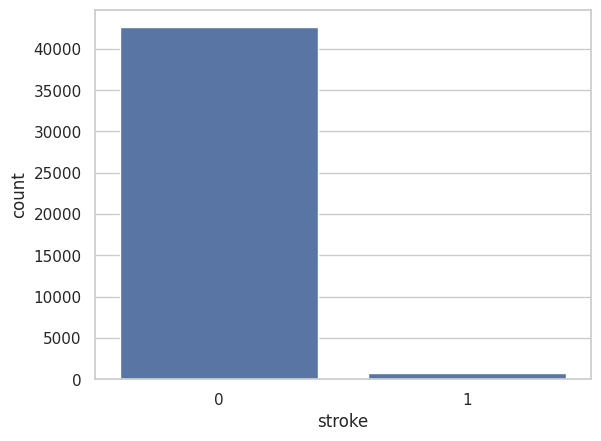

In [103]:
# Count the number of occurrences of the class
class_counts = df['stroke'].value_counts()

# Print the counts of each class
print("Class counts:\n", class_counts)

# Create the count plot for 'Stroke'
sns.countplot(x='stroke', data=df)
plt.show()

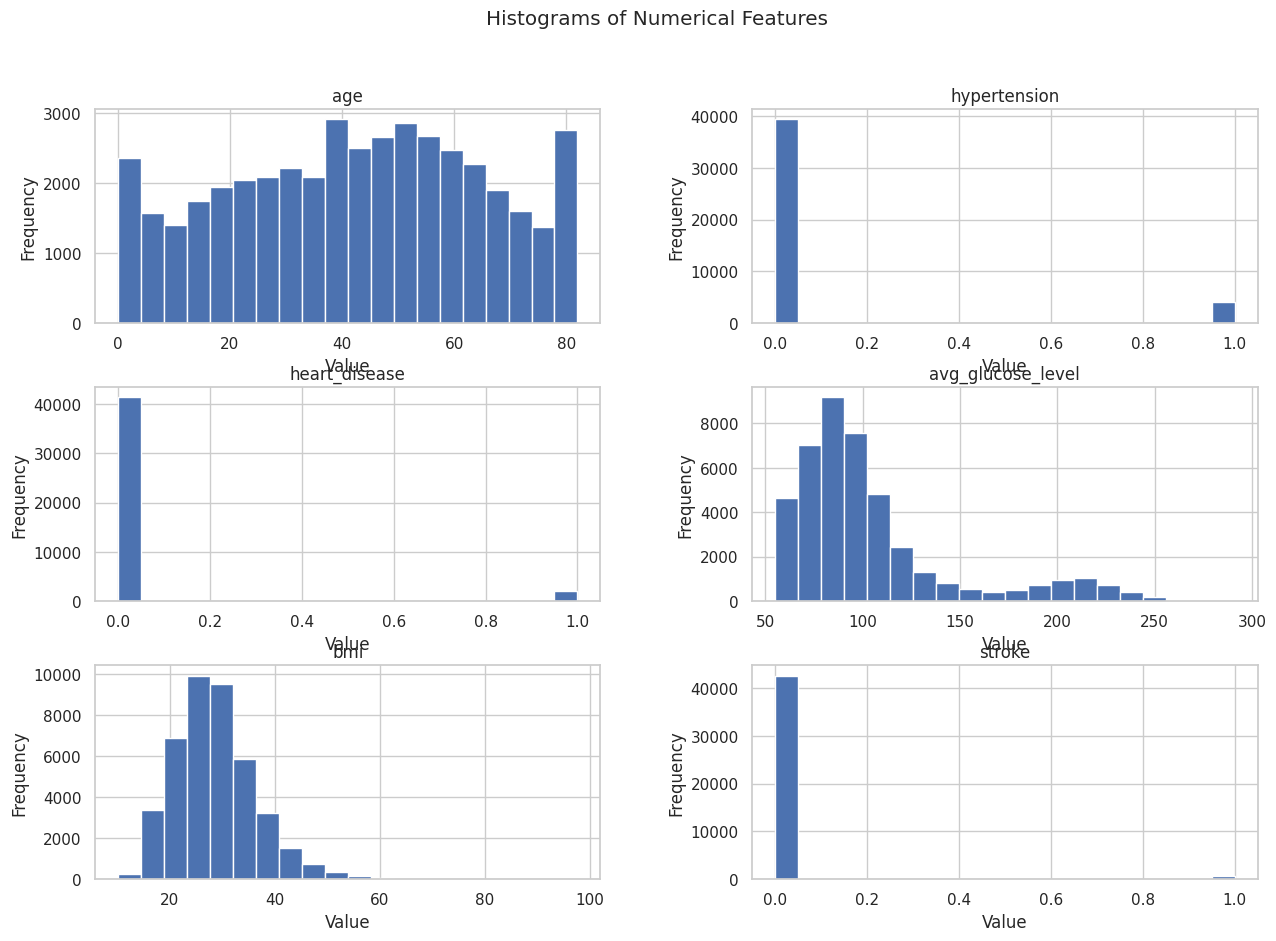

In [45]:
# Plot histograms for numerical features
ax = df.select_dtypes(include='number').hist(bins=20, figsize=(15, 10))

# Set labels for x and y axes
for axes in ax.flatten():
    axes.set_xlabel('Value')  # Label for x-axis
    axes.set_ylabel('Frequency')  # Label for y-axis

# Add title for the entire plot
plt.suptitle("Histograms of Numerical Features")
plt.show()

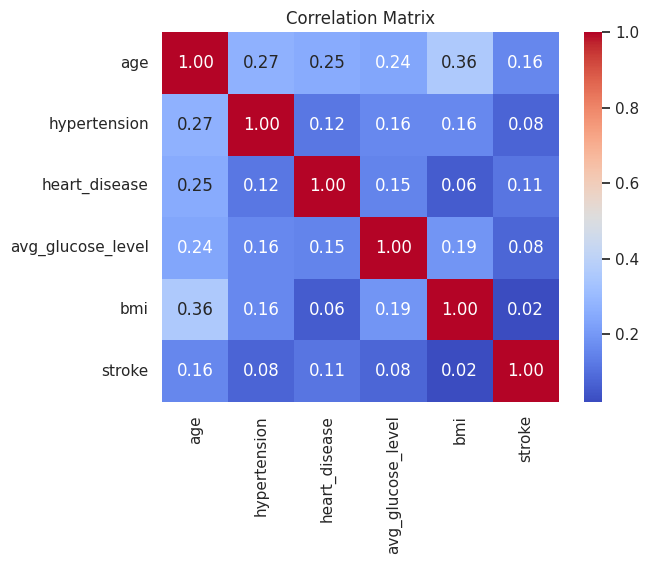

In [46]:
# Select only numerical columns
numerical_data = df.select_dtypes(include='number')

# Compute the correlation matrix for numerical columns
correlation_matrix = numerical_data.corr()

# Plot the heatmap
plt.figure()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

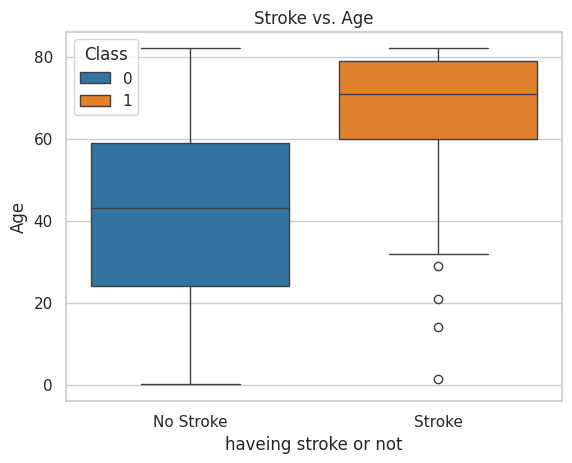

In [47]:
plt.figure()
sns.boxplot(x='stroke', y="age", hue='stroke', data=df, palette="tab10")
plt.xlabel("haveing stroke or not")
plt.ylabel("Age")
plt.title("Stroke vs. Age")
plt.xticks([0, 1], ["No Stroke", "Stroke"])
plt.legend(title="Class")
plt.show()

In [48]:
df.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,3.0,0,0,No,children,Rural,95.12,18.0,NaN,0
1,Male,58.0,1,0,Yes,Private,Urban,87.96,39.2,never smoked,0
2,Female,8.0,0,0,No,Private,Urban,110.89,17.6,NaN,0
3,Female,70.0,0,0,Yes,Private,Rural,69.04,35.9,formerly smoked,0
4,Male,14.0,0,0,No,Never_worked,Rural,161.28,19.1,NaN,0


<Axes: xlabel='smoking_status', ylabel='count'>

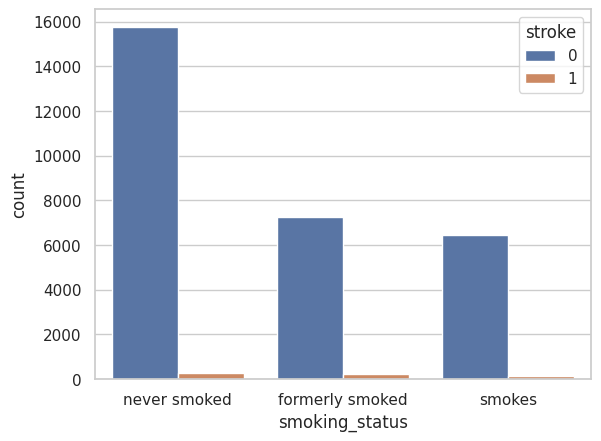

In [49]:
sns.countplot(x='smoking_status',hue = 'stroke', data=df)

<Axes: xlabel='ever_married', ylabel='count'>

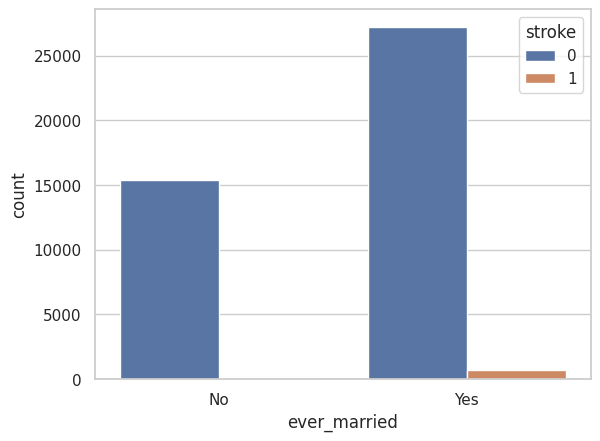

In [50]:
sns.countplot(x='ever_married',hue = 'stroke', data=df)

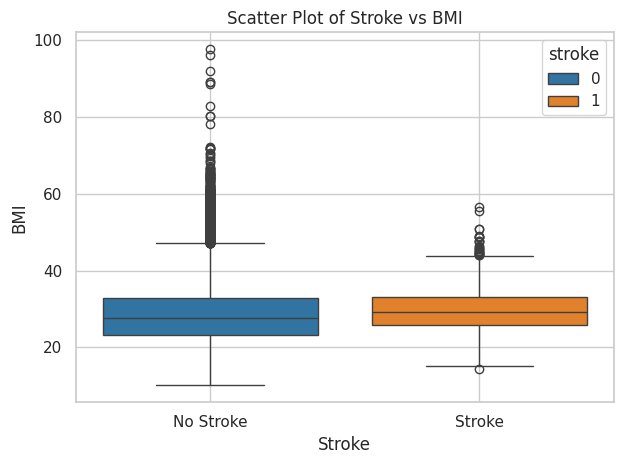

In [51]:
sns.boxplot(x='stroke', y="bmi", hue='stroke', data=df, palette="tab10")  # Stroke on x-axis, BMI on y-axis
plt.xlabel("Stroke")
plt.ylabel("BMI")

plt.title("Scatter Plot of Stroke vs BMI")
plt.xticks([0, 1], ["No Stroke", "Stroke"])
plt.grid(True)
plt.tight_layout()
plt.show()

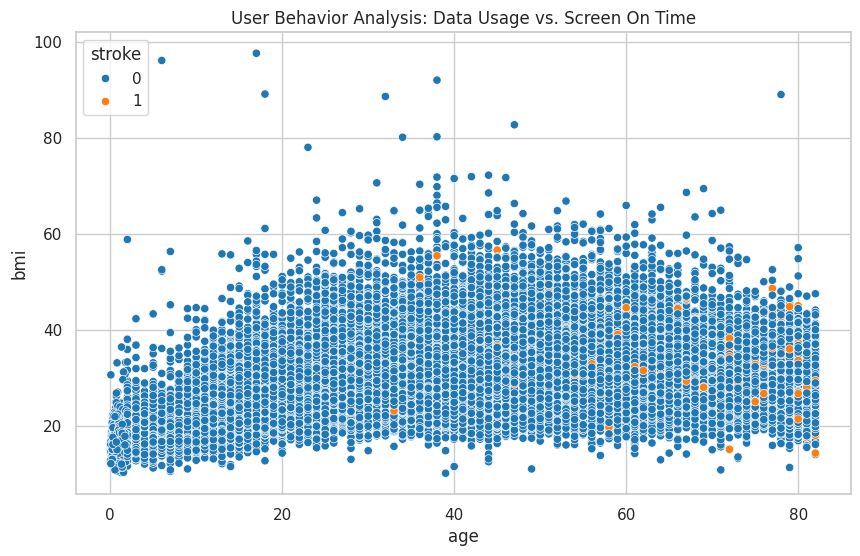

In [52]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='age', y="bmi", hue='stroke', data=df, palette="tab10")
plt.xlabel("age")
plt.ylabel("bmi")
plt.title("User Behavior Analysis: Data Usage vs. Screen On Time")
plt.show()

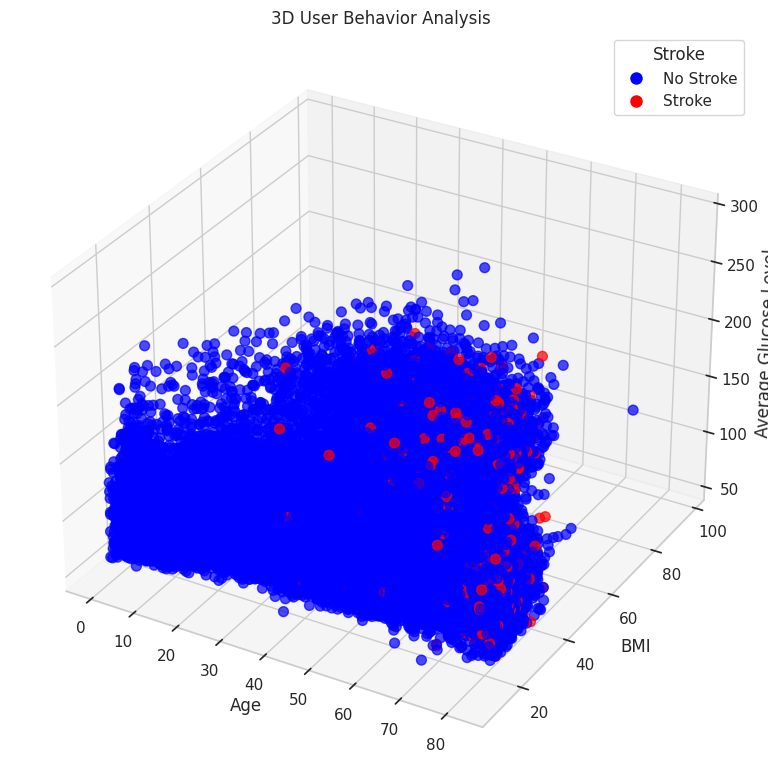

In [53]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Map stroke to colors: 0 -> blue, 1 -> red
colors = df['stroke'].map({0: 'blue', 1: 'red'})

# Create 3D scatter plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    df['age'],
    df['bmi'],
    df['avg_glucose_level'],
    c=colors,
    s=50,
    alpha=0.7
)

# Axis labels
ax.set_xlabel("Age")
ax.set_ylabel("BMI")
ax.set_zlabel("Average Glucose Level")
ax.set_title("3D User Behavior Analysis")

# Custom legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='No Stroke', markerfacecolor='blue', markersize=10),
    Line2D([0], [0], marker='o', color='w', label='Stroke', markerfacecolor='red', markersize=10)
]
ax.legend(handles=legend_elements, title="Stroke")

plt.tight_layout()
plt.show()


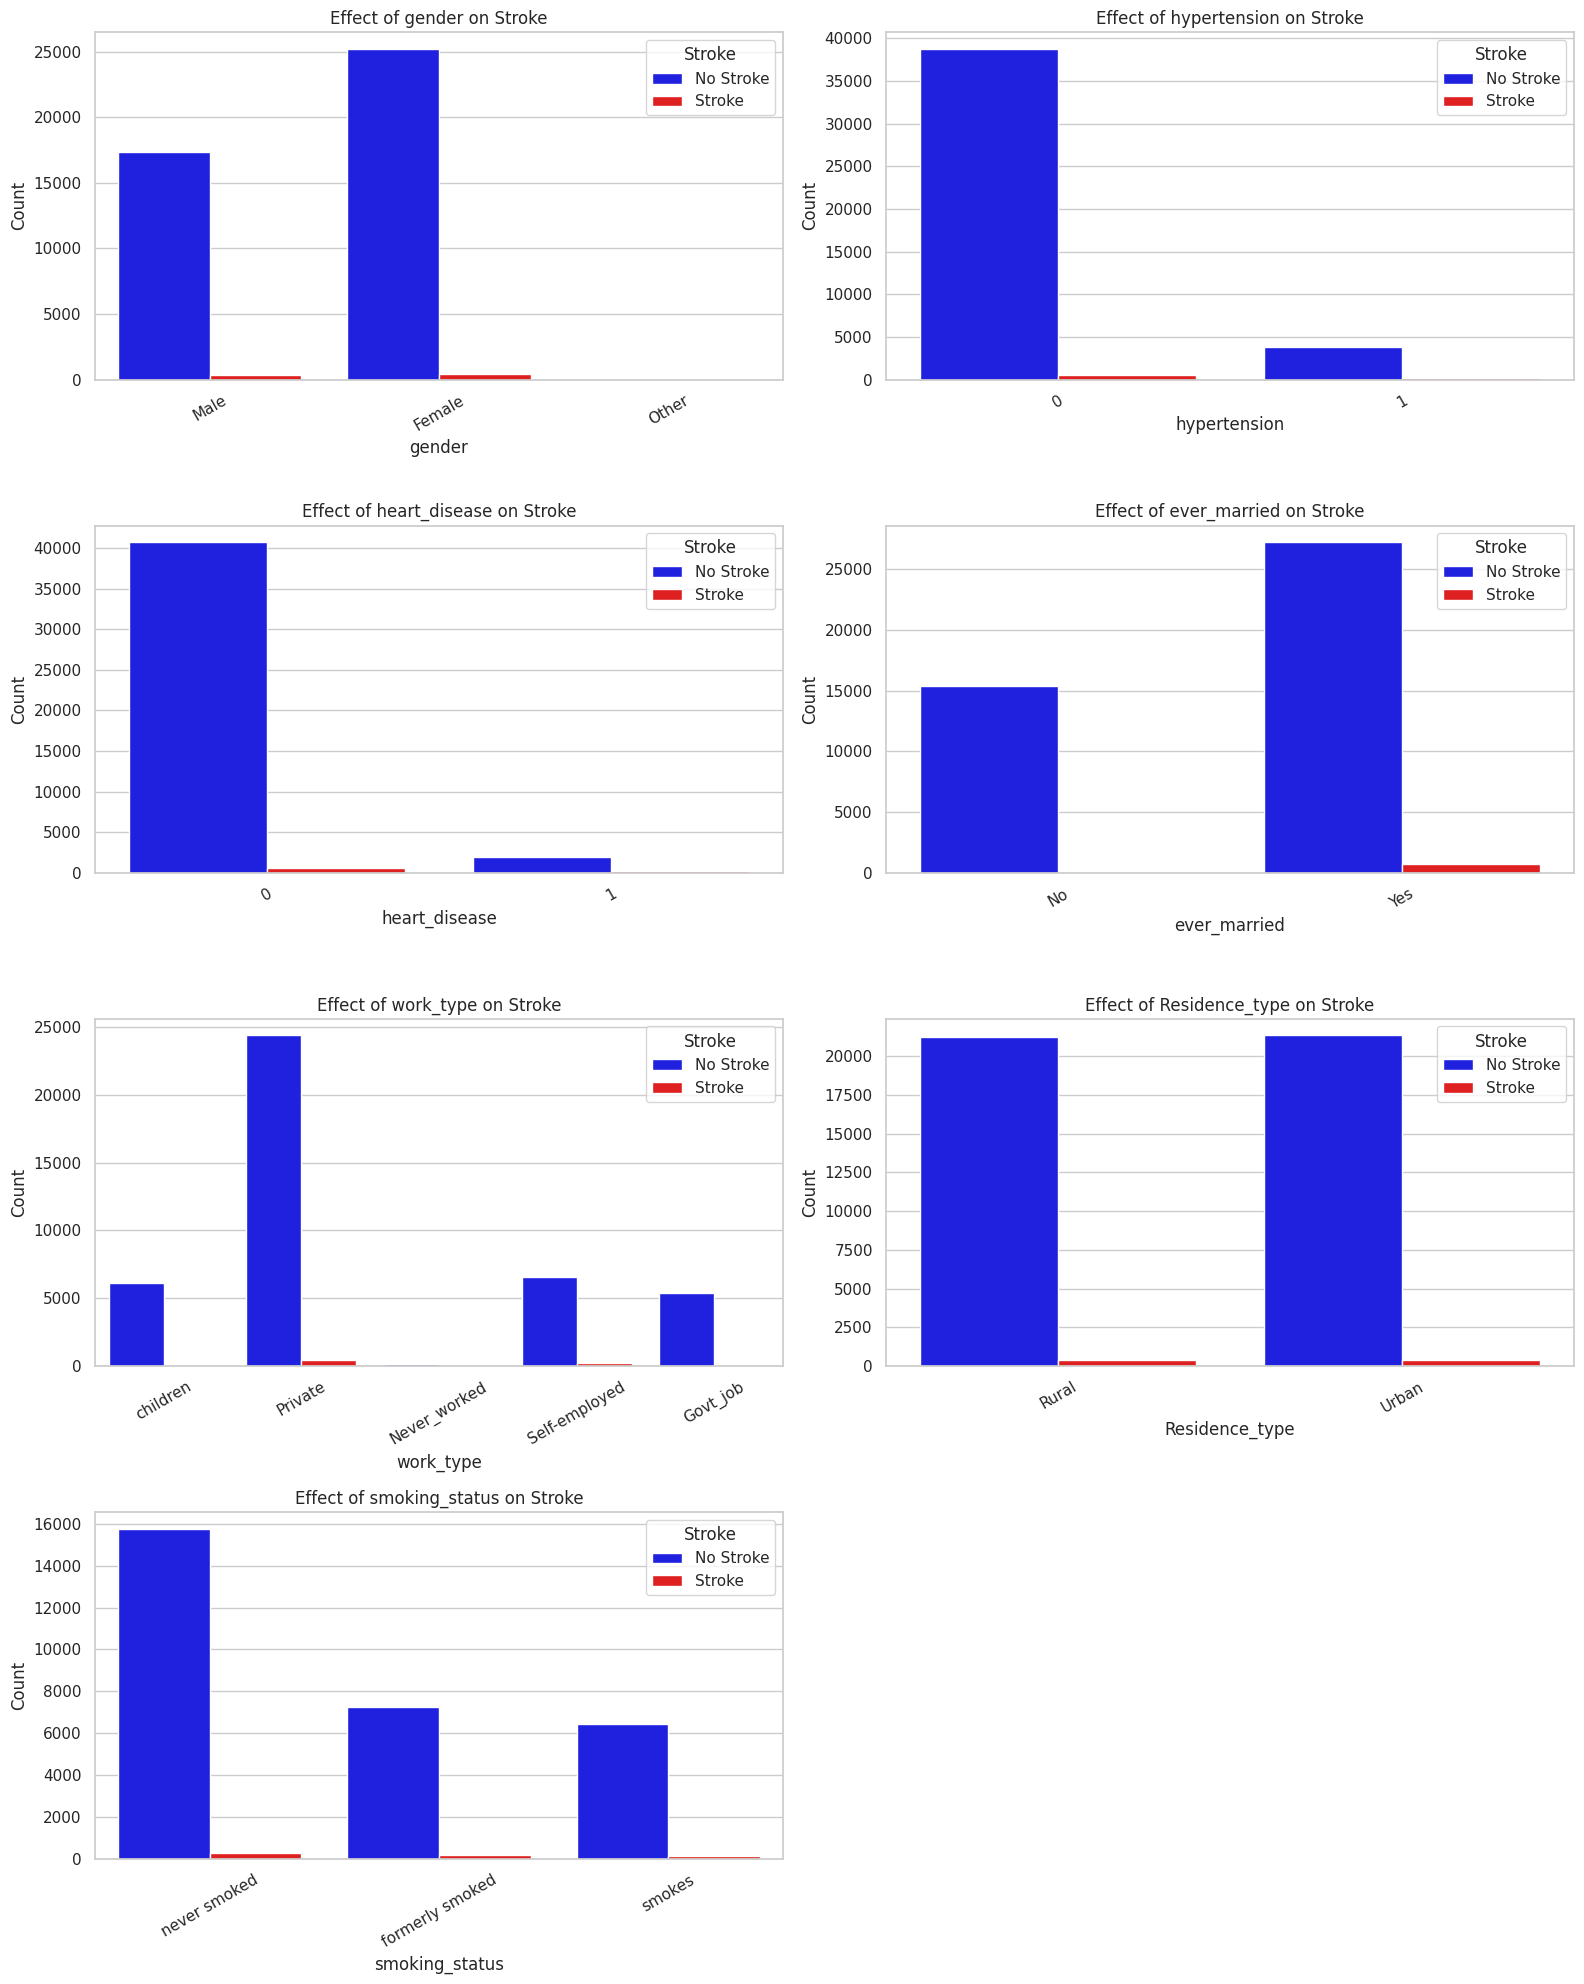

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns

# List of categorical features to plot
categorical_features = [
    'gender', 'hypertension', 'heart_disease', 'ever_married',
    'work_type', 'Residence_type', 'smoking_status'
]

# Plot settings
sns.set(style="whitegrid")
plt.figure(figsize=(16, 20))

# Create subplots for categorical features
for i, feature in enumerate(categorical_features, 1):
    plt.subplot(4, 2, i)
    sns.countplot(data=df, x=feature, hue='stroke', palette={0: 'blue', 1: 'red'})
    plt.title(f"Effect of {feature} on Stroke")
    plt.xlabel(feature)
    plt.ylabel("Count")
    plt.xticks(rotation=30)
    plt.legend(title="Stroke", labels=["No Stroke", "Stroke"])

plt.tight_layout()
plt.show()


<ipython-input-55-84430015eed8>:15: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[i], color='b', shade=True)
<ipython-input-55-84430015eed8>:15: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[i], color='b', shade=True)
<ipython-input-55-84430015eed8>:15: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[i], color='b', shade=True)
<ipython-input-55-84430015eed8>:15: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[i], color='b', shade=True)
<ipython-input-55-84430015eed8>:15: FutureWarning: 

`sh

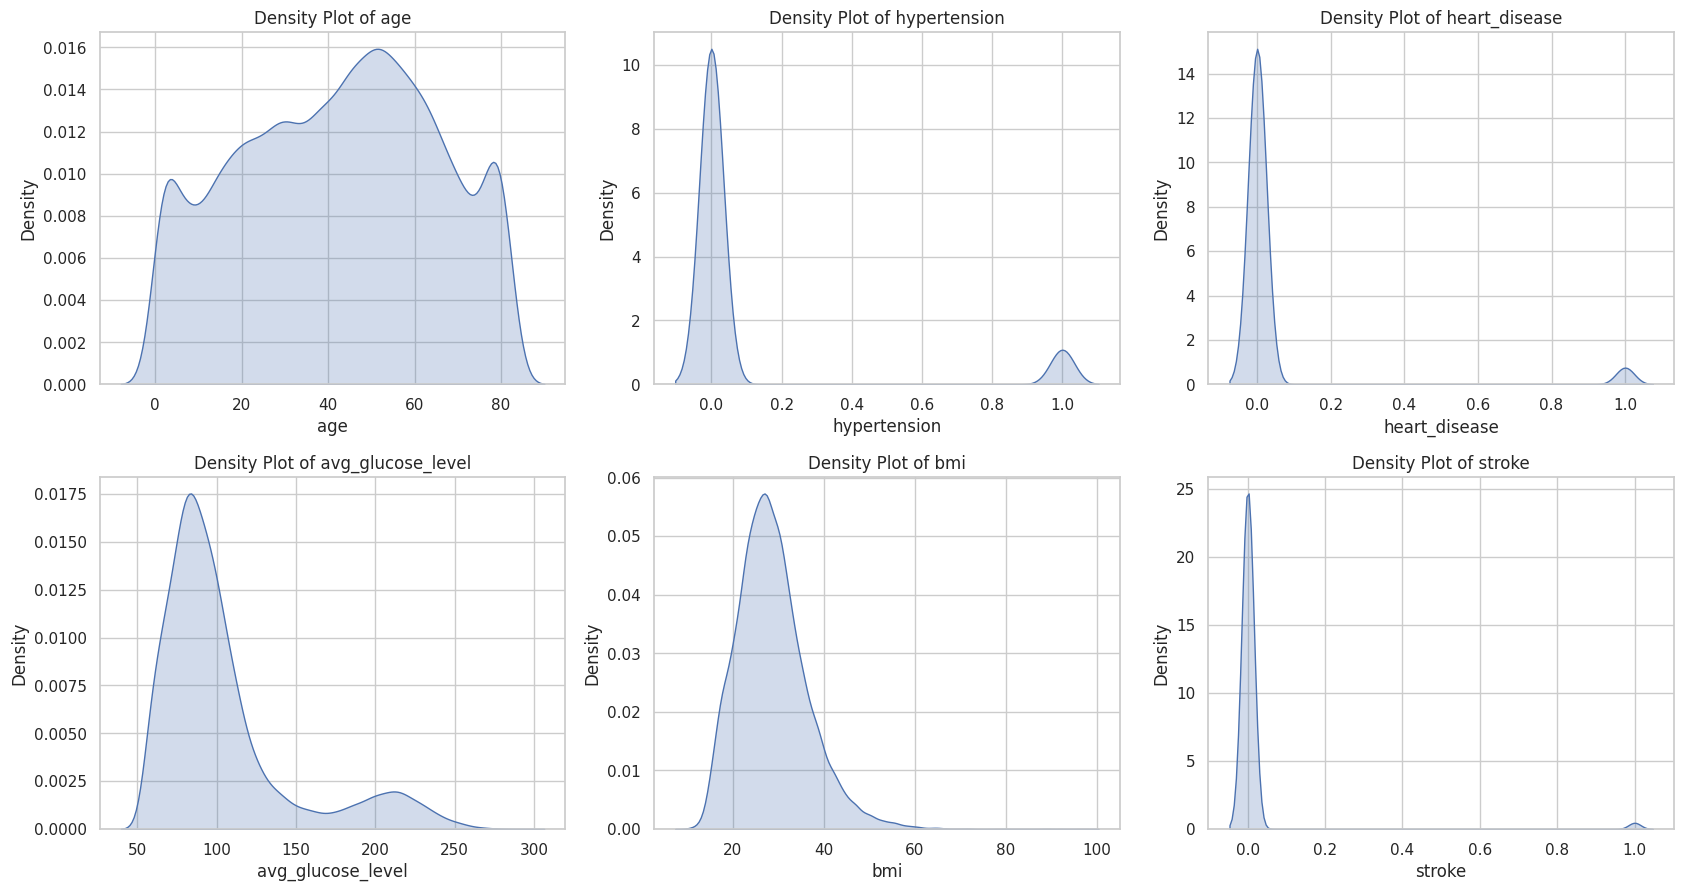

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define the numerical columns from your dataframe
# Assuming you want to use all the numerical columns excluding 'stroke'
numerical_columns = df.select_dtypes(include=['float64', 'int64']).columns.tolist()

# Plot density plots for each numerical feature
plt.figure(figsize=(17, 13))
col = 1

# Loop over numerical columns and plot their density
for i in numerical_columns:
    plt.subplot(3, 3, col)
    sns.kdeplot(df[i], color='b', shade=True)
    plt.title(f'Density Plot of {i}')
    col += 1

plt.tight_layout()
plt.show()


/usr/local/lib/python3.11/dist-packages/seaborn/axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
/usr/local/lib/python3.11/dist-packages/seaborn/axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
/usr/local/lib/python3.11/dist-packages/seaborn/axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
/usr/local/lib/python3.11/dist-packages/seaborn/axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
/usr/local/lib/python3.11/dist-packages/seaborn/axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
/usr/local/lib/python3.11/dist-packages/seaborn/axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable h

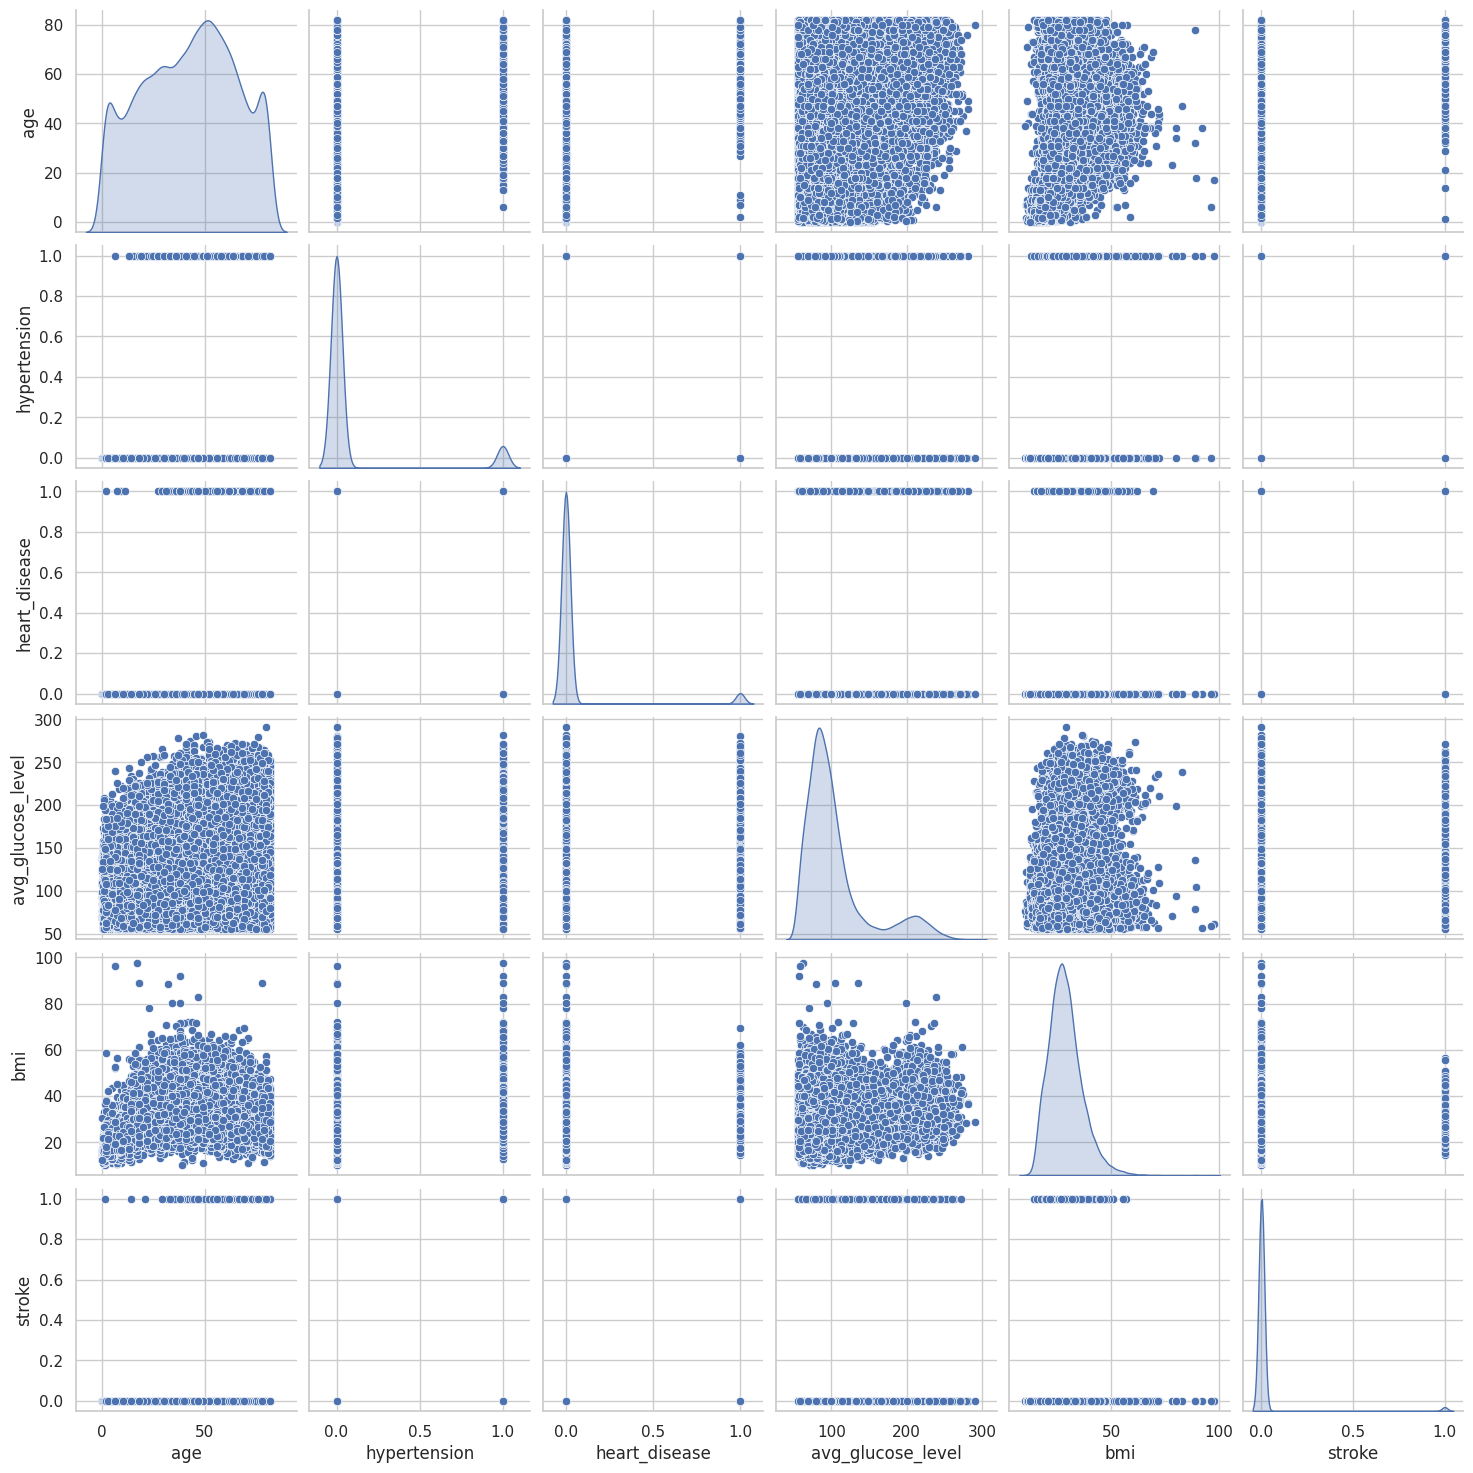

In [56]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select numeric columns from your dataframe (adjust to your columns if necessary)
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns

# Create a pairplot for numeric attributes with KDE on the diagonal
sns.pairplot(df[numeric_cols], diag_kind='kde', palette="viridis")

# Show the plot
plt.show()


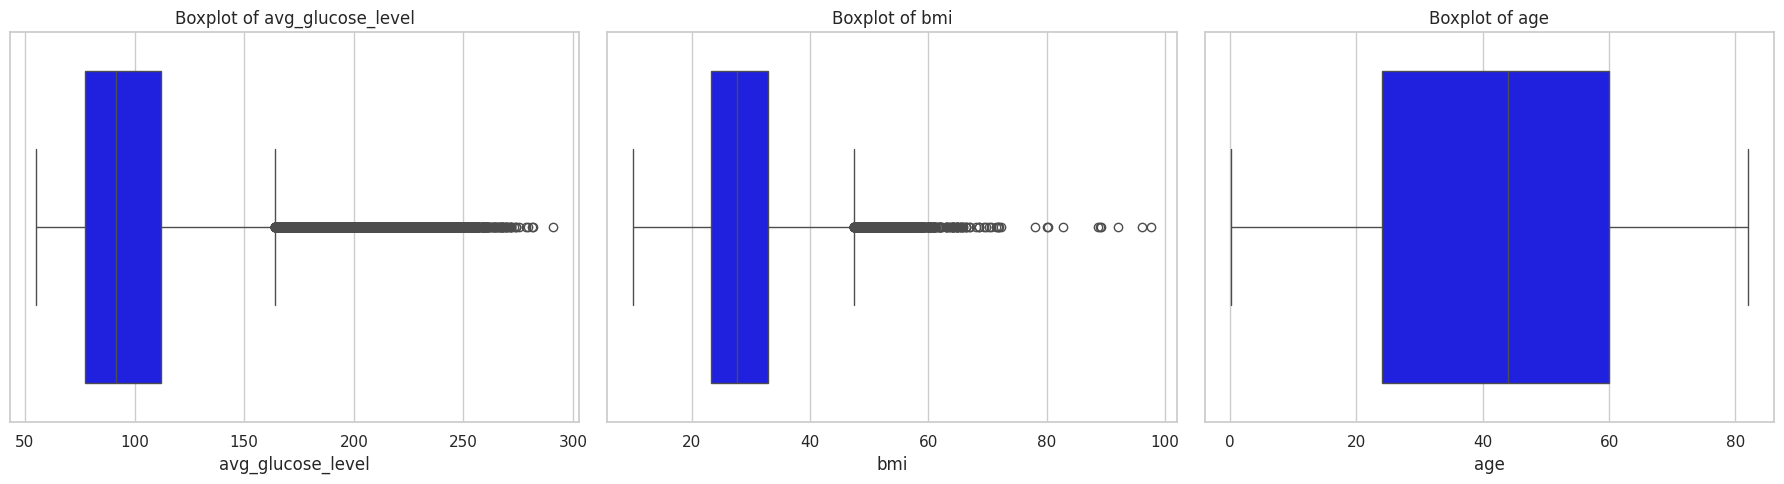

In [57]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select only the features you want
selected_columns = ['avg_glucose_level', 'bmi', 'age']

# Create boxplots to check for outliers
plt.figure(figsize=(18, 5))
col = 1

for i in selected_columns:
    plt.subplot(1, 3, col)
    sns.boxplot(x=df[i], color='blue')
    plt.title(f'Boxplot of {i}')
    col += 1

plt.tight_layout()
plt.show()



## **Pre-processing**

In [104]:
from sklearn.impute import SimpleImputer

# Impute missing 'bmi' values with mean
imputer = SimpleImputer(strategy='mean')
df['bmi'] = imputer.fit_transform(df[['bmi']])

# Find the most frequent smoking_status
most_frequent = df['smoking_status'].mode()[0]

# Fill missing smoking_status with that most frequent value
df['smoking_status'] = df['smoking_status'].fillna(most_frequent)

print(df.isnull().sum())

gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64


In [105]:
print(df['gender'].unique())


['Male' 'Female' 'Other']


In [106]:
print(df['gender'].value_counts())


gender
Female    25665
Male      17724
Other        11
Name: count, dtype: int64


In [107]:
df['gender'] = df['gender'].replace('Other', 'Female')


In [108]:
from sklearn.preprocessing import LabelEncoder

# Label Encoding for binary columns
le = LabelEncoder()
df['gender'] = le.fit_transform(df['gender'])
df['ever_married'] = le.fit_transform(df['ever_married'])
df['Residence_type'] = le.fit_transform(df['Residence_type'])





df.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,1,3.0,0,0,0,children,0,95.12,18.0,never smoked,0
1,1,58.0,1,0,1,Private,1,87.96,39.2,never smoked,0
2,0,8.0,0,0,0,Private,1,110.89,17.6,never smoked,0
3,0,70.0,0,0,1,Private,0,69.04,35.9,formerly smoked,0
4,1,14.0,0,0,0,Never_worked,0,161.28,19.1,never smoked,0


In [109]:
from sklearn.preprocessing import LabelEncoder

# Label Encoding for binary columns
df['gender'] = LabelEncoder().fit_transform(df['gender'])
df['ever_married'] = LabelEncoder().fit_transform(df['ever_married'])
df['Residence Type'] = LabelEncoder().fit_transform(df['Residence_type'])




In [110]:
#One-Hot Encoding for 'work_type' and 'smoking_status'
df = pd.get_dummies(df, columns=['work_type', 'smoking_status'], dtype=int)


df.head()

,gender,age,hypertension,heart_disease,ever_married,Residence_type,avg_glucose_level,bmi,stroke,Residence Type,work_type_Govt_job,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
0,1,3.0,0,0,0,0,95.12,18.0,0,0,0,0,0,0,1,0,1,0
1,1,58.0,1,0,1,1,87.96,39.2,0,1,0,0,1,0,0,0,1,0
2,0,8.0,0,0,0,1,110.89,17.6,0,1,0,0,1,0,0,0,1,0
3,0,70.0,0,0,1,0,69.04,35.9,0,0,0,0,1,0,0,1,0,0
4,1,14.0,0,0,0,0,161.28,19.1,0,0,0,1,0,0,0,0,1,0


In [111]:
#Feature Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df[['age', 'Aavg_glucose_level', 'bmi']] = scaler.fit_transform(df[['age', 'avg_glucose_level', 'bmi']])

df.head()

,gender,age,hypertension,heart_disease,ever_married,Residence_type,avg_glucose_level,bmi,stroke,Residence Type,work_type_Govt_job,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes,Aavg_glucose_level
0,1,-1.741517,0,0,0,0,95.12,-1.388469,0,0,0,0,0,0,1,0,1,0,-0.217176
1,1,0.700823,1,0,1,1,87.96,1.387150,0,1,0,0,1,0,0,0,1,0,-0.383258
2,0,-1.519486,0,0,0,1,110.89,-1.440839,0,1,0,0,1,0,0,0,1,0,0.148621
3,0,1.233697,0,0,1,0,69.04,0.955096,0,0,0,0,1,0,0,1,0,0,-0.822123
4,1,-1.253049,0,0,0,0,161.28,-1.244451,0,0,0,1,0,0,0,0,1,0,1.317458


In [112]:
print(df['stroke'].value_counts())

stroke
0    42617
1      783
Name: count, dtype: int64


In [113]:
print(df['gender'].unique())


[1 0]


In [114]:
from imblearn.over_sampling import SMOTE
X = df.drop('stroke', axis=1)
y = df['stroke']


smote = SMOTE(sampling_strategy='auto', random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

print(pd.Series(y_resampled).value_counts())

df_balanced = pd.DataFrame(X_resampled, columns=X.columns)
df_balanced['stroke'] = y_resampled

data_balanced=df_balanced.copy()



stroke
0    42617
1    42617
Name: count, dtype: int64


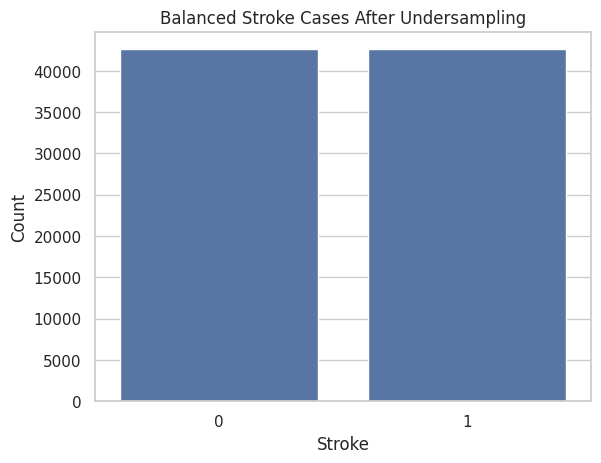

In [69]:
sns.countplot(x='stroke', data=df_balanced)
plt.title('Balanced Stroke Cases After Undersampling')
plt.xlabel('Stroke')
plt.ylabel('Count')
plt.show()

# PCA

In [115]:
X_balanced= df_balanced.drop('stroke', axis=1)
y = df_balanced['stroke']

In [116]:
from sklearn.decomposition import PCA
import pandas as pd


pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_balanced)

print(pca.explained_variance_ratio_)


components = pd.DataFrame(pca.components_, columns=X_balanced.columns)

print(components)


[9.98732854e-01 3.82954027e-04]
     gender       age  hypertension  heart_disease  ever_married  \
0 -0.000187  0.004698      0.000420       0.000588      0.001257   
1 -0.053389  0.851764      0.047816       0.029907      0.255891   

   Residence_type  avg_glucose_level       bmi  Residence Type  \
0       -0.000903           0.999713  0.002994       -0.000903   
1       -0.036473          -0.005798  0.367558       -0.036473   

   work_type_Govt_job  work_type_Never_worked  work_type_Private  \
0           -0.000135               -0.000016          -0.000280   
1           -0.002754               -0.003250           0.019005   

   work_type_Self-employed  work_type_children  \
0                -0.000243           -0.000624   
1                 0.094255           -0.171797   

   smoking_status_formerly smoked  smoking_status_never smoked  \
0                       -0.000064                    -0.001273   
1                        0.069086                    -0.147108   

   smokin

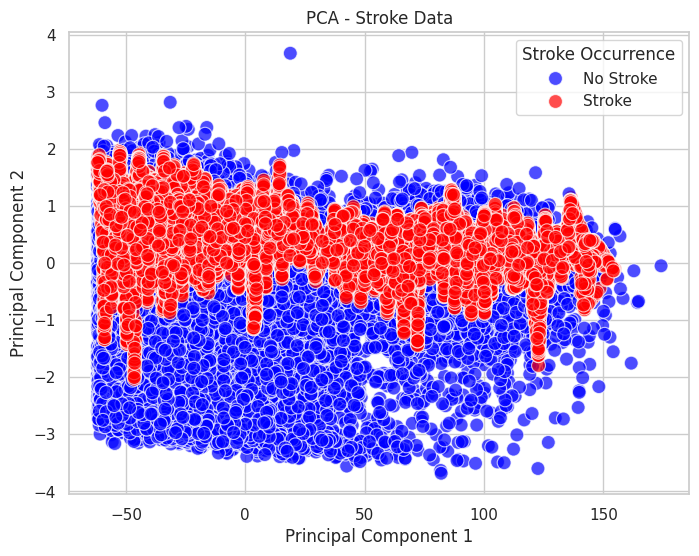

In [117]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))

sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=df_balanced['stroke'], palette={0: 'blue', 1: 'red'}, s=100, alpha=0.7)


plt.title('PCA - Stroke Data')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')


handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles=handles, labels=['No Stroke', 'Stroke'], title='Stroke Occurrence')


plt.show()



In [118]:
#Split into Train and Test Sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_balanced, y, test_size=0.2, random_state=42)

In [119]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score


# KMeans

In [75]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=2, random_state=42)

kmeans_clusters = kmeans.fit_predict(X_pca)

          KMeans Model Evaluation

Internal Evaluation:
Silhouette Score: 0.774
Calinski-Harabasz Index: 446467.425
Davies-Bouldin Index: 0.313

External Evaluation:
Adjusted Rand Index: 0.043
Normalized Mutual Info: 0.051


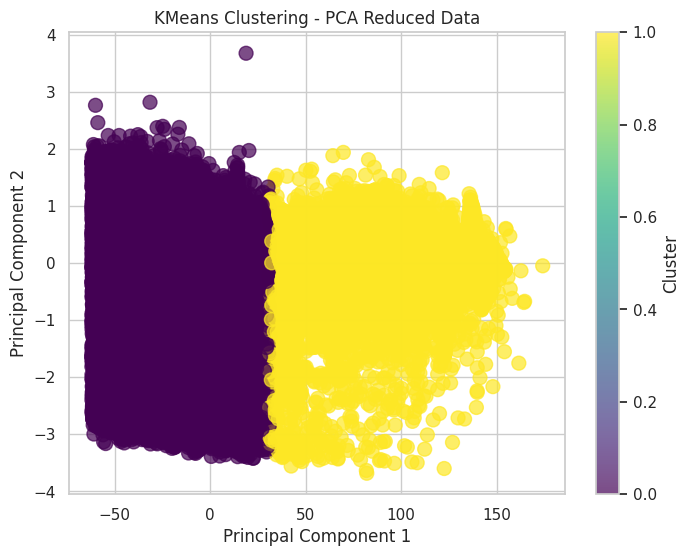

In [76]:
print("""\
=============================================
          KMeans Model Evaluation
=============================================""")

print("\nInternal Evaluation:")
print(f"Silhouette Score: {silhouette_score(X_pca, kmeans_clusters):.3f}")
print(f"Calinski-Harabasz Index: {calinski_harabasz_score(X_pca, kmeans_clusters):.3f}")
print(f"Davies-Bouldin Index: {davies_bouldin_score(X_pca, kmeans_clusters):.3f}")

if 'stroke' in df_balanced.columns:
    print("\nExternal Evaluation:")
    print(f"Adjusted Rand Index: {adjusted_rand_score(df_balanced['stroke'], kmeans_clusters):.3f}")
    print(f"Normalized Mutual Info: {normalized_mutual_info_score(df_balanced['stroke'], kmeans_clusters):.3f}")

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_clusters, cmap='viridis', s=100, alpha=0.7)
plt.title('KMeans Clustering - PCA Reduced Data')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(label='Cluster')
plt.show()

# DBSCAN

In [77]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.5, min_samples=5)
dbscan_clusters = dbscan.fit_predict(X_pca)

In [78]:
n_clusters = len(set(dbscan_clusters)) - (1 if -1 in dbscan_clusters else 0)

print(f"\nNumber of clusters found: {n_clusters}")

print("""\
=============================================
          DBSCAN Model Evaluation
=============================================""")
# Internal Evaluation
print("\nInternal Evaluation:")
if n_clusters > 1:
    print(f"Silhouette Score: {silhouette_score(X_pca, dbscan_clusters):.3f}")
    print(f"Calinski-Harabasz Index: {calinski_harabasz_score(X_pca, dbscan_clusters):.3f}")
    print(f"Davies-Bouldin Index: {davies_bouldin_score(X_pca, dbscan_clusters):.3f}")
else:
    print("Only one cluster found. Silhouette/CH/Davies-Bouldin scores are not meaningful.")


if 'stroke' in df_balanced.columns:
    print("\nExternal Evaluation:")
    print(f"Adjusted Rand Index: {adjusted_rand_score(df_balanced['stroke'], dbscan_clusters):.3f}")
    print(f"Normalized Mutual Info: {normalized_mutual_info_score(df_balanced['stroke'], dbscan_clusters):.3f}")


Number of clusters found: 16
          DBSCAN Model Evaluation

Internal Evaluation:
Silhouette Score: -0.077
Calinski-Harabasz Index: 57.693
Davies-Bouldin Index: 1.266

External Evaluation:
Adjusted Rand Index: 0.000
Normalized Mutual Info: 0.009


# Hierarchical Clustering

In [79]:
from sklearn.cluster import AgglomerativeClustering
# Using a subset approach
sample_size = 10000  # Adjust based on your memory
subset_indices = np.random.choice(len(X_pca), sample_size, replace=False)
X_pca_subset = X_pca[subset_indices]

hierarchical = AgglomerativeClustering(n_clusters=2, linkage='ward')
hierarchical_clusters = hierarchical.fit_predict(X_pca_subset)

print("""\
=============================================
    Hierarchical Model Evaluation
=============================================""")

# Internal Evaluation
print("\nInternal Evaluation:")
print(f"Silhouette Score: {silhouette_score(X_pca_subset, hierarchical_clusters):.3f}")
print(f"Calinski-Harabasz Index: {calinski_harabasz_score(X_pca_subset, hierarchical_clusters):.3f}")
print(f"Davies-Bouldin Index: {davies_bouldin_score(X_pca_subset, hierarchical_clusters):.3f}")

# External Evaluation
if 'stroke' in df_balanced.columns:
    y_subset = df_balanced['stroke'].iloc[subset_indices]
    print("\nExternal Evaluation:")
    print(f"Adjusted Rand Index: {adjusted_rand_score(y_subset, hierarchical_clusters):.3f}")
    print(f"Normalized Mutual Info: {normalized_mutual_info_score(y_subset, hierarchical_clusters):.3f}")

    Hierarchical Model Evaluation

Internal Evaluation:
Silhouette Score: 0.715
Calinski-Harabasz Index: 37441.215
Davies-Bouldin Index: 0.434

External Evaluation:
Adjusted Rand Index: 0.040
Normalized Mutual Info: 0.036


# gmm

In [120]:
from sklearn.mixture import GaussianMixture

features_for_clustering = X_balanced.copy()

# تدريب GMM
gmm = GaussianMixture(n_components=2, random_state=42)
gmm_clusters = gmm.fit_predict(X_pca)


In [123]:

# ======= التقييم الداخلي =======
print("=============================================")
print("          GMM Model Evaluation")
print("=============================================\n")

print("Internal Evaluation:")
print(f"Silhouette Score: {silhouette_score(features_for_clustering, gmm_clusters):.3f}")
print(f"Calinski-Harabasz Index: {calinski_harabasz_score(features_for_clustering, gmm_clusters):.3f}")
print(f"Davies-Bouldin Index: {davies_bouldin_score(features_for_clustering, gmm_clusters):.3f}")

# ======= التقييم الخارجي =======
print("\nExternal Evaluation:")
print(f"Adjusted Rand Index: {adjusted_rand_score(df_balanced['stroke'], gmm_clusters):.3f}")
print(f"Normalized Mutual Info: {normalized_mutual_info_score(df_balanced['stroke'], gmm_clusters):.3f}")





          GMM Model Evaluation

Internal Evaluation:
Silhouette Score: 0.765
Calinski-Harabasz Index: 416877.356
Davies-Bouldin Index: 0.324

External Evaluation:
Adjusted Rand Index: 0.050
Normalized Mutual Info: 0.059


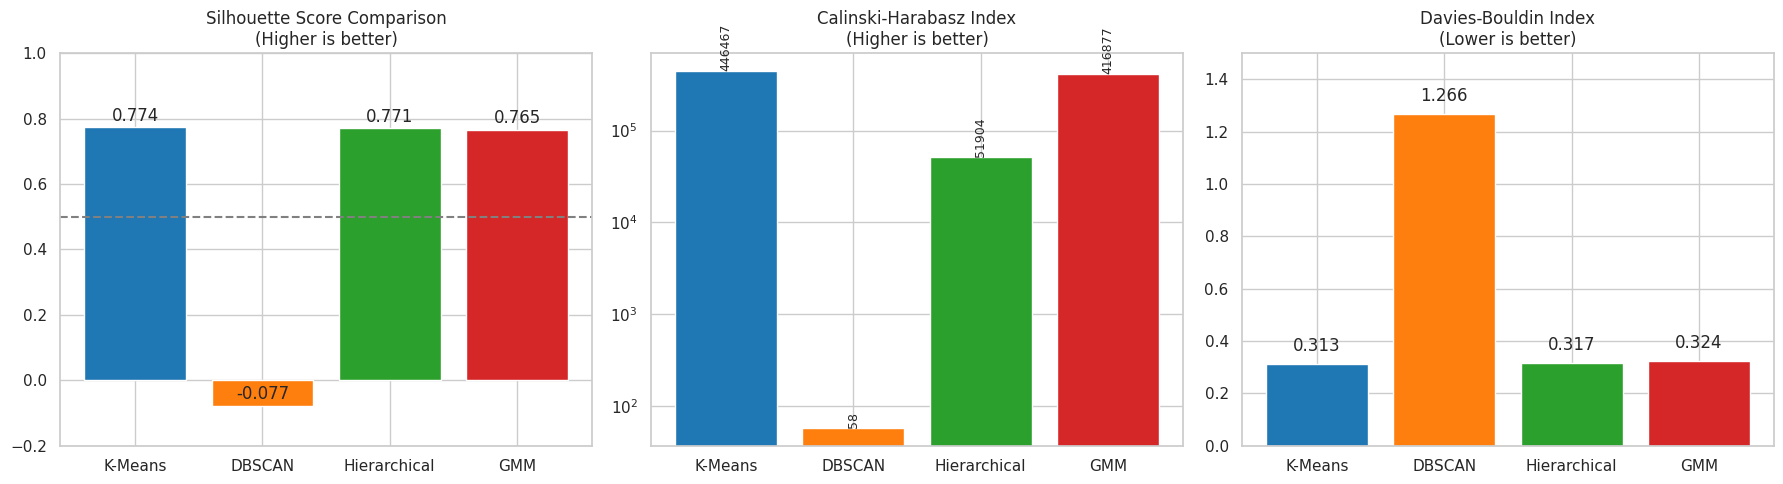

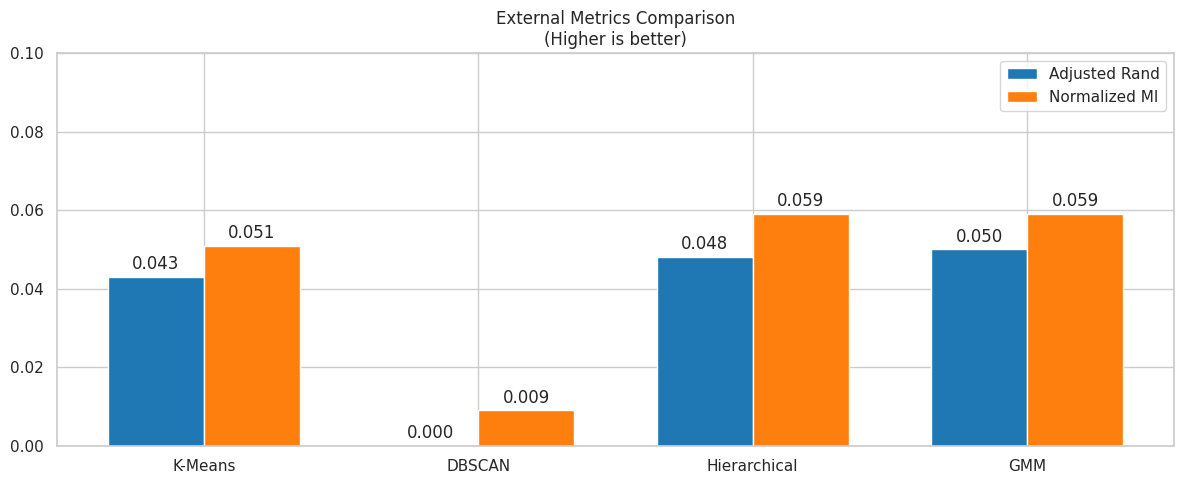

In [124]:
# Prepare evaluation metrics data
models = ['K-Means', 'DBSCAN', 'Hierarchical', 'GMM']
internal_metrics = {
    'Silhouette': [0.774, -0.077, 0.771, 0.765],
    'Calinski-Harabasz': [446467, 57.7, 51904, 416877],
    'Davies-Bouldin': [0.313, 1.266, 0.317, 0.324]
}

external_metrics = {
    'Adjusted Rand': [0.043, 0.000, 0.048, 0.050],
    'Normalized MI': [0.051, 0.009, 0.059, 0.059]
}

# 1. Internal Metrics Comparison
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
plt.bar(models, internal_metrics['Silhouette'], color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
plt.title('Silhouette Score Comparison\n(Higher is better)')
plt.ylim(-0.2, 1)
plt.axhline(y=0.5, color='gray', linestyle='--')
for i, v in enumerate(internal_metrics['Silhouette']):
    plt.text(i, v + 0.02, f"{v:.3f}", ha='center')

plt.subplot(1, 3, 2)
plt.bar(models, internal_metrics['Calinski-Harabasz'], color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
plt.title('Calinski-Harabasz Index\n(Higher is better)')
plt.yscale('log')
for i, v in enumerate(internal_metrics['Calinski-Harabasz']):
    plt.text(i, v, f"{v:.0f}", ha='center', va='bottom', fontsize=9, rotation=90)

plt.subplot(1, 3, 3)
plt.bar(models, internal_metrics['Davies-Bouldin'], color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
plt.title('Davies-Bouldin Index\n(Lower is better)')
plt.ylim(0, 1.5)
for i, v in enumerate(internal_metrics['Davies-Bouldin']):
    plt.text(i, v + 0.05, f"{v:.3f}", ha='center')

plt.tight_layout()
plt.show()

# 2. External Metrics Comparison
plt.figure(figsize=(12, 5))

x = np.arange(len(models))
width = 0.35

plt.bar(x - width/2, external_metrics['Adjusted Rand'], width, label='Adjusted Rand', color='#1f77b4')
plt.bar(x + width/2, external_metrics['Normalized MI'], width, label='Normalized MI', color='#ff7f0e')

plt.xticks(x, models)
plt.title('External Metrics Comparison\n(Higher is better)')
plt.ylim(0, 0.1)
for i in range(len(models)):
    plt.text(x[i] - width/2, external_metrics['Adjusted Rand'][i] + 0.002, f"{external_metrics['Adjusted Rand'][i]:.3f}", ha='center')
    plt.text(x[i] + width/2, external_metrics['Normalized MI'][i] + 0.002, f"{external_metrics['Normalized MI'][i]:.3f}", ha='center')

plt.legend()
plt.tight_layout()
plt.show()


# **Supervised**

In [125]:
df_balanced["cluster"] = kmeans_clusters
stroke_per_cluster = df_balanced.groupby("cluster")["stroke"].mean()
print("cluster:")
print(stroke_per_cluster)

cluster:
cluster
0    0.432443
1    0.724232
Name: stroke, dtype: float64


In [138]:
# now trying wiht ORIGINAL DATAFRAME WITH NO CLUSTERS
#   NORMAL SUPERVISED WITHOUT CLUSTER
X = df.drop('stroke', axis=1)
y = df['stroke']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [139]:
# ---- Train Supervised Models AFTER Adding Clustering Feature ----
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def train_and_evaluate_clustered(X_train_, X_test, y_train, y_test, title=""):
    print(f"\n=== {title} ===")
    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred)
        rec = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)

        print(f"\nModel: {name}")
        print(f"Accuracy: {acc:.4f}")
        print(f"Precision: {prec:.4f}")
        print(f"Recall: {rec:.4f}")
        print(f"F1 Score: {f1:.4f}")


train_and_evaluate_clustered(X_train, X_test, y_train, y_test, title="Supervised Models without clusters")


=== Supervised Models without clusters ===

Model: Logistic Regression
Accuracy: 0.7372
Precision: 0.0546
Recall: 0.8075
F1 Score: 0.1023

Model: Random Forest
Accuracy: 0.9815
Precision: 0.5000
Recall: 0.0062
F1 Score: 0.0123

Model: Gradient Boosting
Accuracy: 0.9811
Precision: 0.2000
Recall: 0.0062
F1 Score: 0.0120


In [140]:
# now trying wiht ORIGINAL DATAFRAME WITH CLUSTERS as a feature
#   NORMAL SUPERVISED with clusters as a feature
X = df_balanced.drop('stroke', axis=1)
y = df_balanced['stroke']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ---- Train Supervised Models AFTER Adding Clustering Feature ----
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def train_and_evaluate_clustered(X_train_, X_test, y_train, y_test, title=""):
    print(f"\n=== {title} ===")
    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred)
        rec = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)

        print(f"\nModel: {name}")
        print(f"Accuracy: {acc:.4f}")
        print(f"Precision: {prec:.4f}")
        print(f"Recall: {rec:.4f}")
        print(f"F1 Score: {f1:.4f}")


train_and_evaluate_clustered(X_train, X_test, y_train, y_test, title="Supervised Models with clusters as a feature")


=== Supervised Models with clusters as a feature ===


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Model: Logistic Regression
Accuracy: 0.8705
Precision: 0.8780
Recall: 0.8614
F1 Score: 0.8696

Model: Random Forest
Accuracy: 0.9839
Precision: 0.9795
Recall: 0.9887
F1 Score: 0.9840

Model: Gradient Boosting
Accuracy: 0.9007
Precision: 0.8964
Recall: 0.9069
F1 Score: 0.9016


# **Risk Factor analysis**

In [141]:
# Add PCA columns to df_balanced
df_balanced['PCA1'] = X_pca[:, 0]
df_balanced['PCA2'] = X_pca[:, 1]

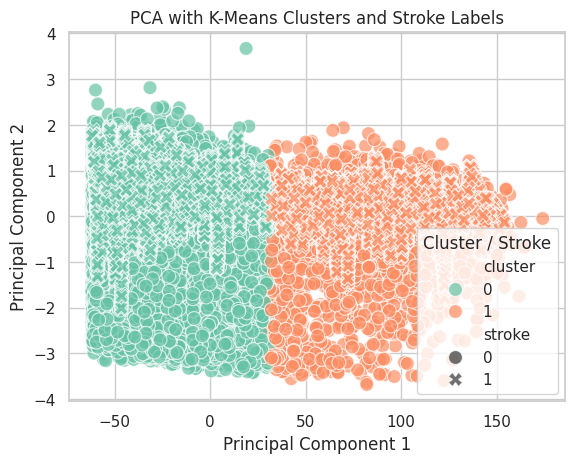

In [142]:
sns.scatterplot(data=df_balanced, x='PCA1', y='PCA2', hue='cluster', style='stroke', palette='Set2', s=100, alpha=0.7)
plt.title('PCA with K-Means Clusters and Stroke Labels')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster / Stroke')
# Overlay K-Means Cluster Assignments

In [143]:
#Feature Contribution to PCA Components
components = pd.DataFrame(pca.components_, columns=X_balanced.columns, index=['PCA1', 'PCA2'])
print(components.T.sort_values(by='PCA1', ascending=False))

                                    PCA1      PCA2
avg_glucose_level               0.999713 -0.005798
Aavg_glucose_level              0.023189 -0.000134
age                             0.004698  0.851764
bmi                             0.002994  0.367558
ever_married                    0.001257  0.255891
heart_disease                   0.000588  0.029907
hypertension                    0.000420  0.047816
work_type_Never_worked         -0.000016 -0.003250
smoking_status_formerly smoked -0.000064  0.069086
work_type_Govt_job             -0.000135 -0.002754
smoking_status_smokes          -0.000177 -0.001730
gender                         -0.000187 -0.053389
work_type_Self-employed        -0.000243  0.094255
work_type_Private              -0.000280  0.019005
work_type_children             -0.000624 -0.171797
Residence_type                 -0.000903 -0.036473
Residence Type                 -0.000903 -0.036473
smoking_status_never smoked    -0.001273 -0.147108


<Figure size 800x400 with 0 Axes>

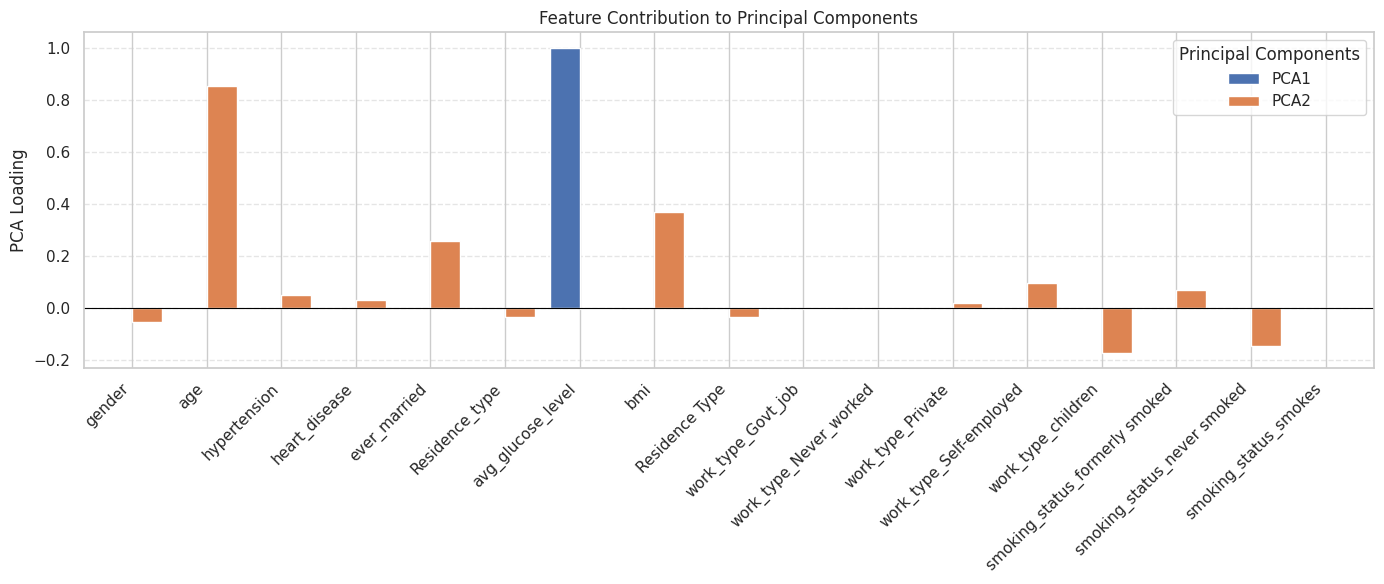

In [149]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


plt.figure(figsize=(8, 4))
components = components.drop(columns=['Aavg_glucose_level'])
components_t = components.T
components_t.plot(kind='bar', figsize=(14, 6), width=0.8)
plt.axhline(0, color='black', linewidth=0.8)
plt.title('Feature Contribution to Principal Components')
plt.ylabel('PCA Loading')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Principal Components')
plt.tight_layout()
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.show()


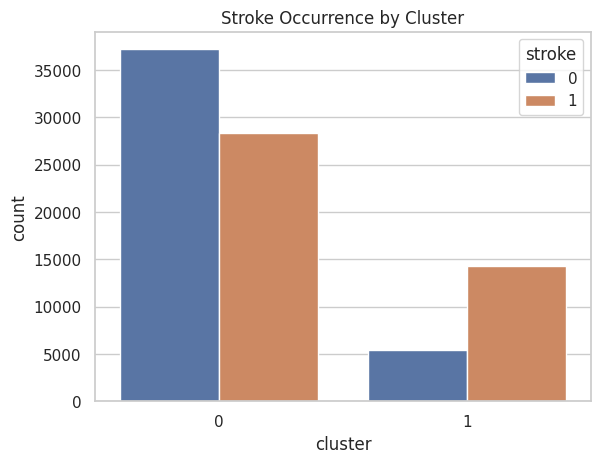

In [145]:
# Stroke rate by cluster
sns.countplot(x='cluster', hue='stroke', data=df_balanced)
plt.title('Stroke Occurrence by Cluster')
plt.show()